In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()


  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`
Precompiling packages...
   6476.8 ms  ✓ CausalSetZoology
  1 dependency successfully precompiled in 21 seconds. 418 already precompiled.


In [2]:
using Revise
using Statistics
using CairoMakie
includet("analysis.jl")


In [3]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [4]:
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

# Link-Degree Skew vs Size for Manifoldlike Simply Connected Datasets

This notebook loads all available `manifoldlike_simply_connected_<size>_10000` statistics files,
computes the skew of the link-degree distribution for each sample, aggregates those skews with
`aggregate_hist_moment`, and plots the mean skew with asymmetric error bars as a function of size.

In [197]:
analysis_root_man = "/Volumes/Causal Set Silo/causal_sets/analysis/"

function manifoldlike_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^manifoldlike_simply_connected_(\d+)_10000$", name)
        msm = match(r"^manifoldlike_simply_connected_(\d+)_1000$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs_man = manifoldlike_size_path_pairs(analysis_root_man)
sizes_man = first.(size_path_pairs_man)
paths_man = last.(size_path_pairs_man)

deleteat!(sizes_man, 10)
deleteat!(paths_man, 10)
deleteat!(sizes_man, 10)
deleteat!(paths_man, 10)

sizes_man


11-element Vector{Int64}:
   256
   300
   400
   512
   600
   700
   800
   900
  1024
  2048
 10000

In [198]:
degree_hists_man = CausalSetZoology.load_histograms_from_paths(paths_man, :degree_hist_link)

11-element Vector{Vector{Dict}}:
 [Dict(5 => 28, 16 => 5, 7 => 33, 12 => 10, 8 => 27, 17 => 1, 1 => 1, 4 => 15, 6 => 34, 13 => 8…), Dict(5 => 28, 16 => 1, 7 => 37, 12 => 9, 8 => 32, 4 => 23, 6 => 40, 13 => 7, 11 => 11, 15 => 4…), Dict(5 => 17, 16 => 1, 7 => 31, 12 => 10, 8 => 30, 19 => 1, 4 => 18, 6 => 33, 13 => 4, 11 => 13…), Dict(5 => 26, 16 => 1, 7 => 31, 12 => 5, 8 => 37, 4 => 9, 6 => 45, 13 => 6, 11 => 20, 15 => 3…), Dict(5 => 23, 16 => 2, 20 => 1, 7 => 33, 12 => 8, 8 => 39, 17 => 1, 1 => 1, 4 => 23, 6 => 32…), Dict(5 => 21, 7 => 49, 12 => 9, 8 => 41, 4 => 11, 6 => 37, 13 => 2, 11 => 17, 15 => 3, 2 => 2…), Dict(5 => 26, 16 => 1, 7 => 26, 12 => 14, 8 => 28, 17 => 1, 1 => 2, 4 => 28, 6 => 34, 13 => 10…), Dict(5 => 24, 16 => 3, 7 => 32, 12 => 13, 8 => 41, 4 => 16, 6 => 36, 13 => 6, 11 => 14, 15 => 1…), Dict(5 => 23, 16 => 1, 7 => 32, 12 => 11, 8 => 31, 1 => 1, 4 => 19, 6 => 25, 13 => 10, 11 => 22…), Dict(5 => 22, 7 => 39, 12 => 17, 8 => 36, 4 => 13, 6 => 32, 13 => 7, 11 => 14, 10 => 

In [199]:
skew_stats_man = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists_man
]

skew_means_man = getfield.(skew_stats_man, :mean)
skew_stds_man = getfield.(skew_stats_man, :std)
skew_lows_man = getfield.(skew_stats_man, :std_lo)
skew_highs_man = getfield.(skew_stats_man, :std_hi)

all(skew_means_man .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes_man[i], mean = skew_means_man[i], std = skew_stds_man[i], std_lo = skew_lows_man[i], std_hi = skew_highs_man[i]) for i in eachindex(sizes_man)]

11-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 256, mean = 0.34708732028518097, std = 0.18554668354679726, std_lo = 0.16057399223886826, std_hi = 0.1807123613825195)
 (size = 300, mean = 0.33766893832014694, std = 0.173275036294145, std_lo = 0.1514024373752033, std_hi = 0.17049212668073382)
 (size = 400, mean = 0.3234321957696209, std = 0.15564380900234162, std_lo = 0.13641959602573286, std_hi = 0.15178965990581428)
 (size = 512, mean = 0.3105400736582133, std = 0.14029313121017617, std_lo = 0.11865842393528958, std_hi = 0.13677028245406325)
 (size = 600, mean = 0.3024721366662521, std = 0.130958443004544, std_lo = 0.11196474841898382, std_hi = 0.12474700777019593)
 (size = 700, mean = 0.2955045121014693, std = 0.1211374736724073, std_lo = 0.10571724018689727, std_hi = 0.11470992730313717)
 (size = 800, mean = 0.2886715601855037, std = 0.113746063190623, std_lo = 0.09802753756941454, std_hi = 0.10786884230927157)
 (s

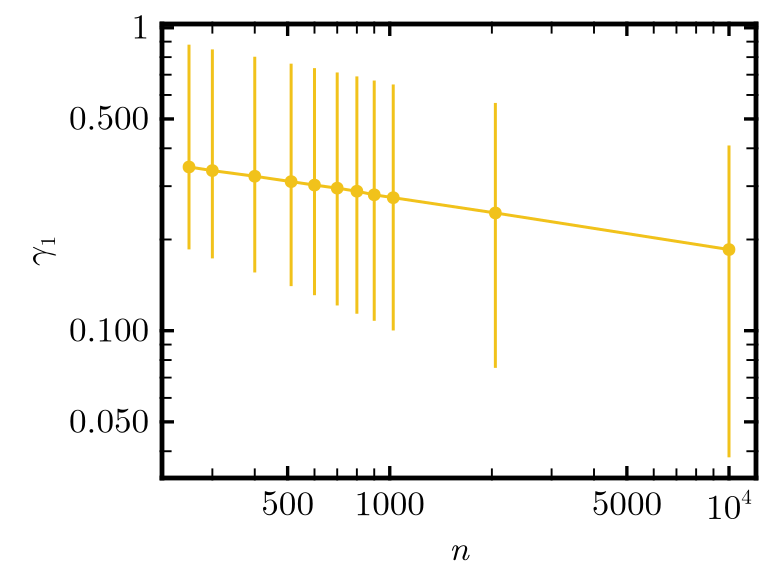

In [200]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
)

errorbars!(ax, sizes_man, skew_means_man, skew_means_man .- skew_stds_man, skew_means_man .+ skew_stds_man,)
scatterlines!(ax, sizes_man, skew_means_man; marker = :circle)

fig


In [201]:
decay_exponent_man = (log(skew_means_man[end]) - log(skew_means_man[1])) / (log(sizes_man[end]) - log(sizes_man[1]))

-0.17128272289296184

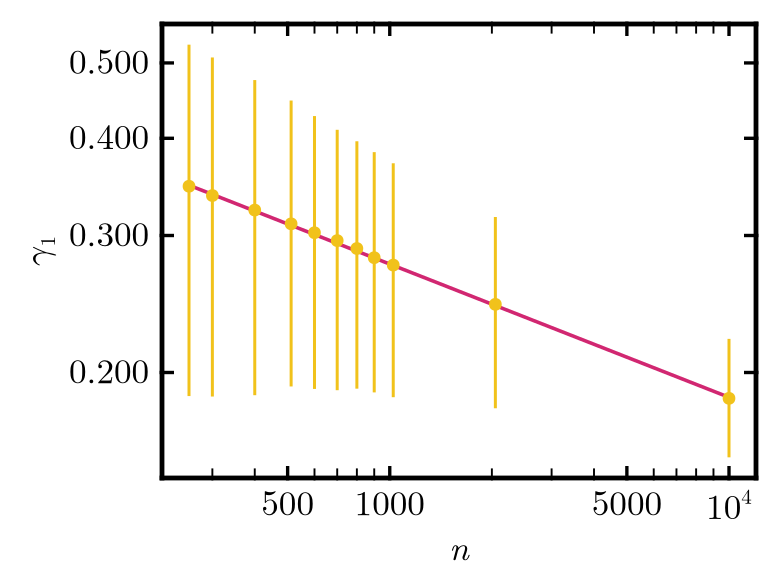

In [202]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
)

lines!(ax, sizes_man,0.9 .* sizes_man .^ decay_exponent_man, color = colors[2])
errorbars!(ax, sizes_man, skew_means_man, skew_lows_man, skew_highs_man,)
scatter!(ax, sizes_man, skew_means_man; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling.pdf"), fig)

fig

# Link-Degree Skew vs Size for Minkowski sprinkling Datasets

In [187]:
analysis_root = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only/"

function minkowski_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^minkowski_sprinkling_link_degree_(\d+)_1000$", name)
        msm = match(r"^minkowski_sprinkling_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs_mink = minkowski_size_path_pairs(analysis_root)
sizes_mink = first.(size_path_pairs_mink)
paths_mink = last.(size_path_pairs_mink)

deleteat!(sizes_mink, 9)
deleteat!(paths_mink, 9)

sizes_mink

8-element Vector{Int64}:
   1024
   2048
   4096
   8192
  16384
  32768
  65536
 131072

In [188]:
degree_hists_mink = CausalSetZoology.load_histograms_from_paths(paths_mink, :degree_hist_link)

8-element Vector{Vector{Dict}}:
 [Dict(5 => 12, 16 => 40, 20 => 1, 7 => 62, 12 => 122, 8 => 75, 17 => 35, 19 => 12, 22 => 1, 4 => 7…), Dict(5 => 21, 16 => 27, 7 => 73, 12 => 113, 8 => 99, 17 => 24, 19 => 2, 4 => 2, 6 => 39, 13 => 88…), Dict(5 => 23, 16 => 40, 20 => 2, 7 => 75, 12 => 119, 24 => 1, 8 => 84, 17 => 19, 19 => 3, 4 => 4…), Dict(5 => 26, 16 => 30, 20 => 1, 12 => 112, 8 => 94, 17 => 17, 1 => 1, 19 => 2, 22 => 1, 6 => 39…), Dict(5 => 9, 16 => 27, 20 => 4, 7 => 57, 12 => 123, 8 => 83, 17 => 19, 23 => 1, 19 => 11, 22 => 1…), Dict(5 => 13, 16 => 34, 20 => 3, 7 => 65, 12 => 123, 8 => 84, 17 => 16, 19 => 5, 4 => 1, 6 => 31…), Dict(5 => 14, 16 => 31, 20 => 2, 7 => 70, 12 => 125, 8 => 97, 17 => 22, 19 => 4, 4 => 6, 6 => 21…), Dict(5 => 16, 16 => 42, 20 => 2, 7 => 61, 12 => 133, 8 => 92, 17 => 18, 19 => 7, 4 => 6, 6 => 32…), Dict(5 => 14, 16 => 43, 20 => 4, 7 => 68, 12 => 137, 8 => 82, 17 => 24, 23 => 1, 19 => 6, 22 => 1…), Dict(5 => 22, 16 => 25, 20 => 1, 7 => 56, 12 => 134, 8 => 101,

In [189]:
skew_stats_mink = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists_mink
]

skew_means_mink = getfield.(skew_stats_mink, :mean)
skew_stds_mink = getfield.(skew_stats_mink, :std)
skew_lows_mink = getfield.(skew_stats_mink, :std_lo)
skew_highs_mink = getfield.(skew_stats_mink, :std_hi)

all(skew_means_mink .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes_mink[i], mean = skew_means_mink[i], std = skew_stds_mink[i], std_lo = skew_lows_mink[i], std_hi = skew_highs_mink[i]) for i in eachindex(sizes_mink)]

8-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 1024, mean = 0.25517991100568693, std = 0.0843177972911055, std_lo = 0.08373731679614213, std_hi = 0.08465021211602286)
 (size = 2048, mean = 0.24951461144573703, std = 0.06142209517880349, std_lo = 0.05969304397255251, std_hi = 0.061561912293536886)
 (size = 4096, mean = 0.23997753972534858, std = 0.040885628544118, std_lo = 0.03762949239911942, std_hi = 0.043797342518013704)
 (size = 8192, mean = 0.2319051965700888, std = 0.029075635995191945, std_lo = 0.027087876222033735, std_hi = 0.028795706643499064)
 (size = 16384, mean = 0.22516858703624745, std = 0.02155592296243637, std_lo = 0.022104518234578957, std_hi = 0.020979427888681595)
 (size = 32768, mean = 0.21935494213432313, std = 0.015145267206643982, std_lo = 0.019124487427931353, std_hi = 0.012783176629710735)
 (size = 65536, mean = 0.21177403002999792, std = 0.010166720165422218, std_lo = 0.008497519797427133, st

In [190]:
decay_exponent_mink = (log(skew_means_mink[end]) - log(skew_means_mink[1])) / (log(sizes_mink[end]) - log(sizes_mink[1]))

-0.046123060727594985

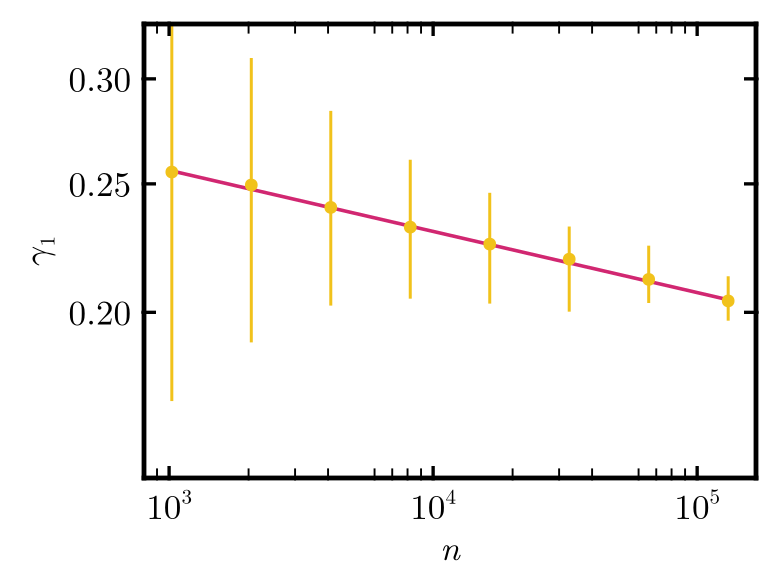

In [204]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
    yticks = [0.2, 0.25, 0.3],
    xticks = ([1e3, 1e4, 1e5], [L"10^3", L"10^4", L"10^5"])
)

ylims!(ax, 0.15, 0.33)

lines!(ax, sizes_mink,0.352 .* sizes_mink .^ decay_exponent_mink, color = colors[2])
errorbars!(ax, sizes_mink, skew_means_mink, min.(skew_means_mink.-1e-6, skew_lows_mink), skew_highs_mink)
scatter!(ax, sizes_mink, skew_means_mink; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling_Minkowski.pdf"), fig)

fig

┌ Warning: Unsupported marker: rectangle, using ● instead. Available options can be printed with `available_marker_symbols()`
└ @ Makie ~/.julia/packages/Makie/kJl0u/src/conversions.jl:2321


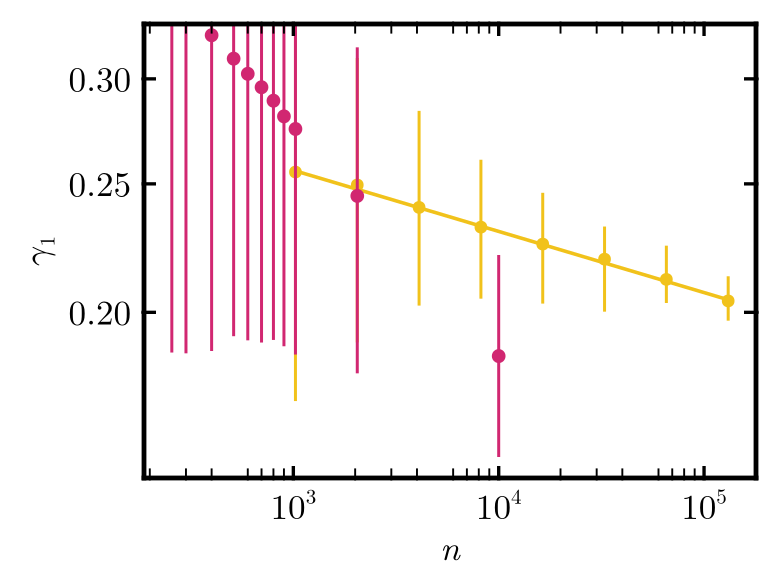

In [205]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
    yticks = [0.2, 0.25, 0.3],
    xticks = ([1e3, 1e4, 1e5], [L"10^3", L"10^4", L"10^5"])
)

ylims!(ax, 0.15, 0.33)

lines!(ax, sizes_mink,0.352 .* sizes_mink .^ decay_exponent_mink, color = colors[1])
errorbars!(ax, sizes_mink, skew_means_mink, min.(skew_means_mink.-1e-6, skew_lows_mink), skew_highs_mink)
scatter!(ax, sizes_mink, skew_means_mink; marker = :circle)

lines!(ax, sizes_man,0.352 .* sizes_man .^ decay_exponent_man, color = colors[2])
errorbars!(ax, sizes_man, skew_means_man, min.(skew_means_man.-1e-6, skew_lows_man), skew_highs_man, color = colors[2])
scatter!(ax, sizes_man, skew_means_man; marker = :rectangle, color = colors[2])


save(fig_path("graph_observables/degree_skew_size_scaling_combined.pdf"), fig)

fig